<a href="https://colab.research.google.com/github/argho626-hue/CivCode-AI/blob/main/CivCode_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Find the file correctly
# 1. Load data directly from GitHub Raw URL
url = "https://raw.githubusercontent.com/argho626-hue/CivCode-AI/main/final.xlsx"
print(f"Loading data directly from GitHub...")

# 2. Load the Data (header=2 means 3rd row in Excel)
df = pd.read_excel(url, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all') # Drop completely empty columns

Loading data directly from GitHub...


Loading data directly from GitHub for model comparison...

Training all models, please wait a few seconds...

Random Forest Accuracy: 86.40%
Gradient Boosting Accuracy: 85.37%
Support Vector Machine Accuracy: 81.04%


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Artificial Neural Network Accuracy: 79.25%


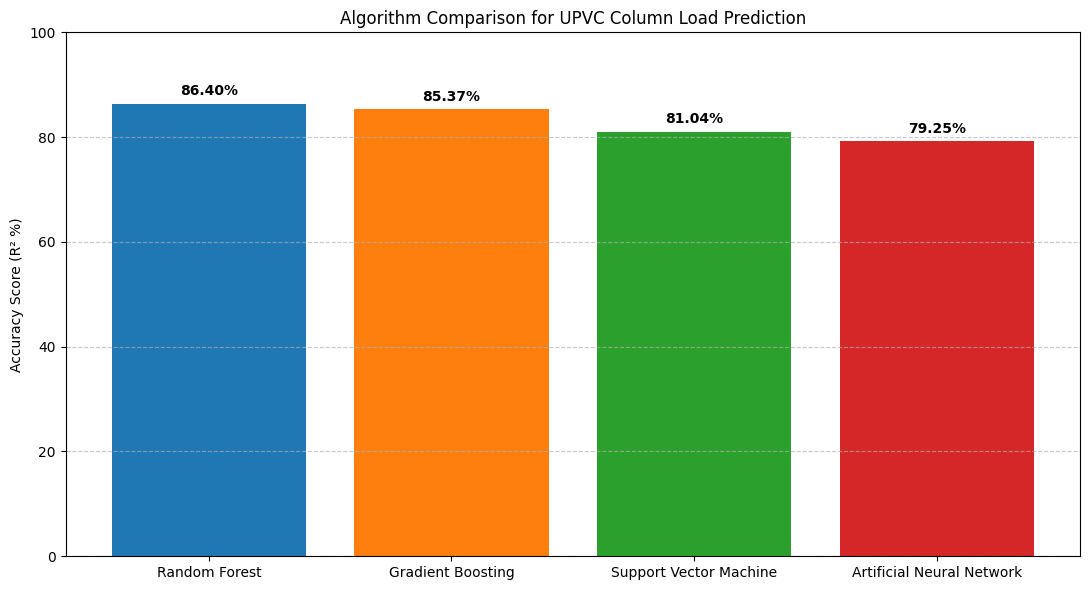

In [38]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1 & 2. Load data directly from GitHub (No manual upload needed!)
url = "https://raw.githubusercontent.com/argho626-hue/CivCode-AI/main/final.xlsx"
print("Loading data directly from GitHub for model comparison...")
df = pd.read_excel(url, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all')

# 3. Clean the 'OUTPUT' column
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])

# 4. Define Features (X) and Target (y)
y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

# Clean columns and force them to numbers
cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Data Scaling (CRUCIAL for SVM and ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Initialize All 4 Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Machine": SVR(kernel='rbf', C=5000, gamma='scale'),
    "Artificial Neural Network": MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)
}

# 8. Train and Record Accuracy
accuracy_results = {}

print("\nTraining all models, please wait a few seconds...\n")
for name, model in models.items():
    if name in ["Support Vector Machine", "Artificial Neural Network"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    accuracy_results[name] = r2 * 100
    print(f"{name} Accuracy: {r2 * 100:.2f}%")

# 9. Plot the Comparison Bar Chart
plt.figure(figsize=(11, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 100)
plt.ylabel('Accuracy Score (R² %)')
plt.title('Algorithm Comparison for UPVC Column Load Prediction')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Loading data directly from GitHub for Feature Importance analysis...


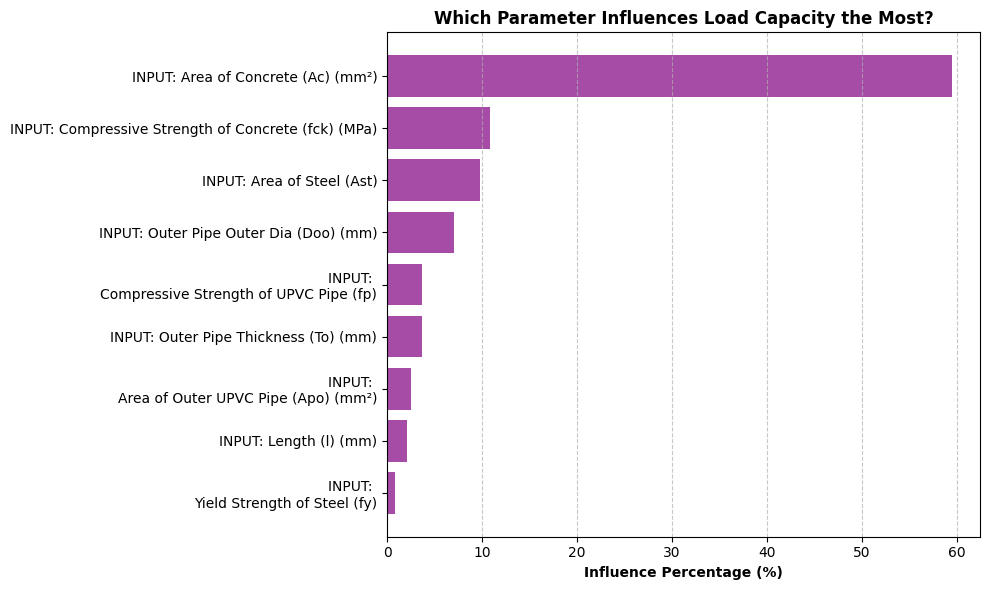

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Load data directly from GitHub (No manual upload needed!)
url = "https://raw.githubusercontent.com/argho626-hue/CivCode-AI/main/final.xlsx"
print("Loading data directly from GitHub for Feature Importance analysis...")
df = pd.read_excel(url, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all')

# 2. Clean Data
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])

y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Train Model & Get Feature Importance
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance Score': importances * 100})
feat_df = feat_df.sort_values(by='Importance Score', ascending=True)

# 4. Plot (Matches your beautiful purple graph!)
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance Score'], color='purple', alpha=0.7)
plt.xlabel('Influence Percentage (%)', fontweight='bold')
plt.title('Which Parameter Influences Load Capacity the Most?', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
import gradio as gr
import pandas as pd
import numpy as np
import gspread
from google.oauth2.service_account import Credentials
from datetime import datetime

# ---------------------------------------------------------
# 0. Database Connection Setup (Global)
# ---------------------------------------------------------
try:
    json_file_name = 'civcode-ai-f5cdaac3e7de.json'
    scopes = ['https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive']
    creds = Credentials.from_service_account_file(json_file_name, scopes=scopes)
    client = gspread.authorize(creds)
    sheet = client.open('CivCode AI User Logs').sheet1
    db_connected = True
    print("✅ Database successfully connected!")
except Exception as e:
    print(f"⚠️ Database connection failed: {e}")
    db_connected = False

# ---------------------------------------------------------
# 1. Reverse Design (AI Optimizer) Logic
# ---------------------------------------------------------
def optimize_design(target_load, L):
    target_load = float(target_load)
    L = float(L)

    fck_list = [20, 25, 30, 40, 50]
    D_list = [90, 110, 140, 160, 200]
    t_list = [2.0, 2.3, 3.2, 4.25, 5.0]

    best_capacity, best_fck, best_D, best_t = 0, 0, 0, 0
    found = False

    for fck in fck_list:
        for D in D_list:
            for t in t_list:
                if (D - 2*t) > 0:
                    A_c = (np.pi/4) * ((D - 2*t)**2)
                    A_upvc = (np.pi/4) * (D**2) - A_c

                    temp_df = pd.DataFrame([[L, t, D, A_c, fck, A_upvc, 0, 0, 0]], columns=X.columns)
                    capacity = model.predict(temp_df)[0]

                    if capacity >= target_load:
                        best_capacity, best_fck, best_D, best_t = capacity, fck, D, t
                        found = True
                        break
            if found: break
        if found: break

    if found:
        result_text = f"✅ MOST ECONOMICAL DESIGN FOUND:\n-----------------------------------\n• Concrete Grade: M{best_fck}\n• UPVC Pipe Outer Dia: {best_D} mm\n• UPVC Pipe Thickness: {best_t} mm\n• AI Estimated Capacity: {best_capacity:.2f} kN\n\n💡 This is the optimal combination to safely carry {target_load} kN!"
    else:
        result_text = "⚠️ No valid design found. Please try a lower target load or increase column length."

    # --- Save Real-Time Data to Google Sheets ---
    if db_connected:
        try:
            current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            log_data = [current_time, f"Target: {target_load}kN, L={L}", f"Best Design: M{best_fck}, D={best_D}mm", "AI Optimizer Run"]
            sheet.append_row(log_data)
        except Exception as e:
            print(f"Logging error: {e}")

    return result_text

# ---------------------------------------------------------
# 2. Main Prediction Logic (Manual)
# ---------------------------------------------------------
def predict_load(L, t, D, A_c, fck, A_upvc, A_s, fy, fp):
    input_data = pd.DataFrame([[L, t, D, A_c, fck, A_upvc, A_s, fy, fp]], columns=X.columns)
    pred = model.predict(input_data)[0]
    result_text = f"⚡ AI Predicted Maximum Load: {pred:.2f} kN"

    # --- Save Real-Time Data to Google Sheets ---
    if db_connected:
        try:
            current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            log_data = [current_time, f"Manual Input: L={L}, D={D}, fck={fck}", result_text, "Manual Predict Run"]
            sheet.append_row(log_data)
        except Exception as e:
            print(f"Logging error: {e}")

    return result_text

# ---------------------------------------------------------
# 3. Custom CSS & HTML for Hero Banner
# ---------------------------------------------------------
custom_css = """
.hero-banner {
    background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%);
    border-radius: 15px;
    padding: 25px;
    margin-bottom: 20px;
    box-shadow: 0 10px 25px rgba(0,0,0,0.5);
    border-left: 5px solid #14b8a6;
    color: white;
}
.hero-title {
    font-size: 2.5em !important;
    font-weight: 800 !important;
    margin-bottom: 0px !important;
    background: -webkit-linear-gradient(45deg, #38bdf8, #34d399);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    text-align: center;
}
.hero-subtitle {
    font-size: 1.1em;
    color: #94a3b8;
    margin-bottom: 15px;
    margin-top: 5px;
}
.badge-container {
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
    margin-bottom: 15px;
}
.badge {
    background: rgba(20, 184, 166, 0.1);
    border: 1px solid rgba(20, 184, 166, 0.3);
    padding: 5px 15px;
    border-radius: 20px;
    font-size: 0.85em;
    color: #5eead4;
    font-weight: 600;
}
.quote {
    font-style: italic;
    color: #cbd5e1;
    font-size: 0.95em;
    border-top: 1px solid rgba(255,255,255,0.1);
    padding-top: 15px;
}
"""

hero_html = """
<div class="hero-banner">
    <!-- AI Logo Added Here -->
    <img src="https://raw.githubusercontent.com/argho626-hue/CivCode-AI/main/CivCODE%20ai%20logo.png" alt="CivCode AI Logo" style="width: 140px; display: block; margin: 0 auto 15px auto; border-radius: 12px; background: white; padding: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.3);">

    <h1 class="hero-title">🏗️ CivCode AI v3.0</h1>
    <p style="color: #cbd5e1; font-size: 1.1em; letter-spacing: 1px; text-align: center; margin-top: 5px; margin-bottom: 25px;">ADVANCED COMPUTATIONAL MECHANICS & SUSTAINABLE STRUCTURES</p>

    <h2 style="margin: 0; font-size: 1.6em; color: white;">Architected by <span style="color: #38bdf8;">Argho Dutta</span></h2>
    <p class="hero-subtitle">🎓 B.Tech Civil Engineering @ HIT | 🌍 Future Sustainable Structural Engineer</p>

    <div class="badge-container">
        <span class="badge">🔬 AAC Researcher (Thermo-Mechanical)</span>
        <span class="badge">🤖 Machine Learning applied to Civil Eng.</span>
        <span class="badge">🏭 HPL & PWD QA/QC Experienced</span>
        <span class="badge">📄 Published Author (The Penlighten)</span>
    </div>

    <div class="quote">
        "Bridging the gap between eco-friendly construction materials and data-driven predictive modeling to eliminate destructive testing."
    </div>
</div>
"""

# ---------------------------------------------------------
# 4. Gradio UI Assembly
# ---------------------------------------------------------
with gr.Blocks(css=custom_css, theme=gr.themes.Monochrome()) as app:
    gr.HTML(hero_html)
    with gr.Tabs():
        with gr.TabItem("1️⃣ Load Prediction (Manual)"):
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### 📏 Dimensions")
                    L = gr.Number(label="Length (mm)")
                    t = gr.Number(label="Outer Pipe Thickness (mm)")
                    D = gr.Number(label="Outer Dia (mm)")
                with gr.Column():
                    gr.Markdown("### 🧱 Material Properties")
                    A_c = gr.Number(label="Area of Concrete (mm²)")
                    fck = gr.Number(label="Concrete Strength - fck (MPa)")
                    A_upvc = gr.Number(label="Area of Outer UPVC Pipe (mm²)")
                with gr.Column():
                    gr.Markdown("### ⚙️ Steel Properties")
                    A_s = gr.Number(label="Area of Steel", value=0)
                    fy = gr.Number(label="Yield Strength of Steel - fy", value=0)
                    fp = gr.Number(label="Compressive Strength of UPVC - fp", value=0)

            predict_btn = gr.Button("🚀 Run AI Structural Simulation", variant="primary")
            pred_output = gr.Textbox(label="AI Prediction Result")
            predict_btn.click(predict_load, inputs=[L, t, D, A_c, fck, A_upvc, A_s, fy, fp], outputs=pred_output)

        with gr.TabItem("2️⃣ Generative Design (AI Optimizer)"):
            gr.Markdown("Enter your **Target Load** to automatically generate the most optimized and economical UPVC-confined column design.")
            with gr.Row():
                target_load = gr.Number(label="Target Load Required (kN)")
                length_opt = gr.Number(label="Column Length (l) (mm)")

            opt_btn = gr.Button("✨ Generate Best Design", variant="primary")
            opt_output = gr.Textbox(label="AI Suggested Best Design", lines=8)
            opt_btn.click(optimize_design, inputs=[target_load, length_opt], outputs=opt_output)

    gr.HTML("""
    <div style="text-align: center; margin-top: 40px; padding: 20px; border-top: 1px solid rgba(255,255,255,0.1);">
        <p style="color: #94a3b8; font-size: 0.95em; margin: 0; letter-spacing: 1px;">
            © 2026 <strong>Argho Dutta</strong> | <span style="color: #38bdf8; font-weight: 600;">CivCode AI v3.0</span>
        </p>
        <p style="color: #64748b; font-size: 0.85em; margin-top: 8px; font-style: italic;">
            Empowering Sustainable Engineering with Data-Driven Intelligence 🌍
        </p>
    </div>
    """)

# 5. Launch the App
app.launch(share=True)

✅ Database successfully connected!


/tmp/ipykernel_2220/2920468293.py:168: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Monochrome()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1661a57176a71209fc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
